In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../data/processed/energy_features_2019.csv')

In [3]:
df.head(6)

,date,hour,avg_energy,temperature,humidity,pressure,is_weekend,is_holiday
0,2019-01-01,0,1.2825,2.0,80.0,103.12,0,1
1,2019-01-01,1,1.4725,2.0,80.0,103.12,0,1
2,2019-01-01,2,1.1825,1.6,82.0,103.08,0,1
3,2019-01-01,3,1.0875,1.9,79.0,103.12,0,1
4,2019-01-01,4,1.0775,1.9,82.0,103.13,0,1
5,2019-01-01,5,1.0750,2.1,80.0,103.08,0,1


In [4]:
RANDOM_STATE = 42
df.sample(10, random_state = RANDOM_STATE)

,date,hour,avg_energy,temperature,humidity,pressure,is_weekend,is_holiday
6056,2019-09-10,8,0.316,16.1,87.0,101.30,0,0
5556,2019-08-20,12,0.276,21.4,64.0,101.26,0,0
5990,2019-09-07,14,0.720,18.9,74.0,101.44,1,0
7674,2019-11-16,18,1.594,10.0,92.0,102.18,1,0
3319,2019-05-19,7,0.250,13.5,76.0,100.60,1,0
5761,2019-08-29,1,0.300,17.1,84.0,101.09,0,0
5972,2019-09-06,20,0.848,20.1,59.0,101.72,0,0
8758,2019-12-31,22,1.246,8.9,96.0,99.85,0,0
6079,2019-09-11,7,0.338,13.8,91.0,101.83,0,0
7177,2019-10-27,1,1.454,4.2,68.0,103.36,1,0


In [5]:
df.avg_energy.values

array([1.2825, 1.4725, 1.1825, ..., 1.188 , 1.246 , 1.494 ])

In [6]:
average_energy_demand = df.avg_energy.values
average_temperature = df.temperature.values

In [7]:
def annual_daily_average(arr:np.typing.NDArray, timestamp = 24) -> np.typing.NDArray:
    
    annual_arr = []
    length_arr = len(arr)
    ele_sum = 0
    
    for ele in range(length_arr):
        
        if (ele+1) % (timestamp) == 0:
            ele_sum += arr[ele]
            annual_arr.append(ele_sum)
            ele_sum = 0
        else:
            ele_sum += arr[ele]

    return np.array(annual_arr)
    
    

In [8]:
annual_daily_energy_demand = annual_daily_average(average_energy_demand)

In [9]:
len(annual_daily_energy_demand)

365

In [10]:
annual_daily_energy_demand[0]

28.650000000000006

In [11]:
df.head(24).sum()

date           2019-01-012019-01-012019-01-012019-01-012019-0...
hour                                                         276
avg_energy                                                 28.65
temperature                                                 72.2
humidity                                                  1875.0
pressure                                                 2471.65
is_weekend                                                     0
is_holiday                                                    24
dtype: object

In [12]:
annual_daily_temp =  annual_daily_average(average_temperature)

In [13]:
annual_daily_temp[0]

72.2

In [14]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
normalized_annual_temp = scaler.fit_transform(annual_daily_temp.reshape(-1,1))
normalized_annual_demand = scaler.fit_transform(annual_daily_energy_demand.reshape(-1,1))
print(len(normalized_annual_demand))
print(len(normalized_annual_temp))

365
365


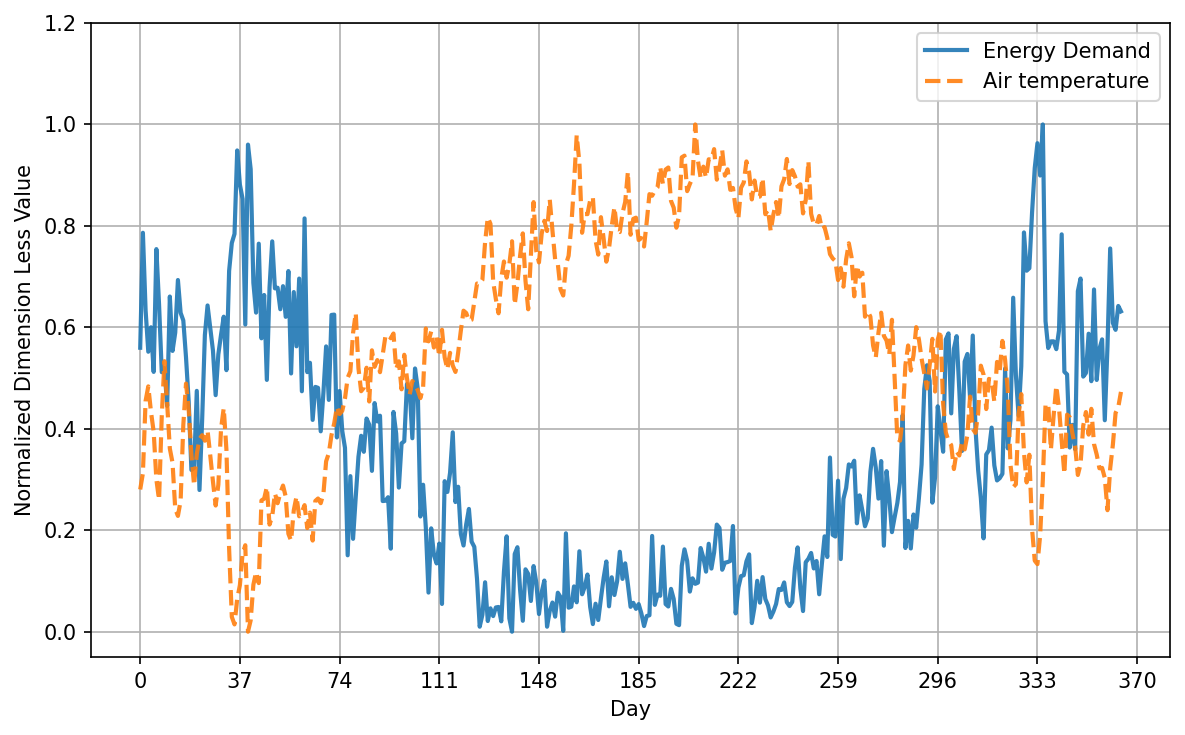

In [37]:
#  Air temperature and energy demand annual trends
plt.figure(figsize=(8,5), dpi = 150)
plt.plot(normalized_annual_demand, linewidth = 2, label= 'Energy Demand', alpha = 0.9)
plt.plot(normalized_annual_temp, linewidth = 2,label = "Air temperature", linestyle = '--', alpha = 0.9)
plt.ylabel('Normalized Dimension Less Value')
plt.xlabel('Day')
plt.xticks(np.arange(0, 400, 37))
plt.yticks(np.arange(0,1.4, 0.2))
plt.grid()
plt.legend(loc = 1)
plt.tight_layout()
plt.savefig('../results/temp_energy_relation.png', dpi = 200)

In [16]:
annual_daily_energy_demand
threshold = 22.1918
low = 0.0941
high = 0.141
energy_price = []
energy_cost = []
for day in range(len(annual_daily_energy_demand)):
    energy = annual_daily_energy_demand[day] 
    if energy > threshold:
        energy_price.append(high)
        energy_cost.append(high*(energy-threshold) + low*threshold)

    else:
        energy_price.append(low)
        energy_cost.append(low*energy)

energy_cost = np.array(energy_cost)
energy_price = np.array(energy_price)




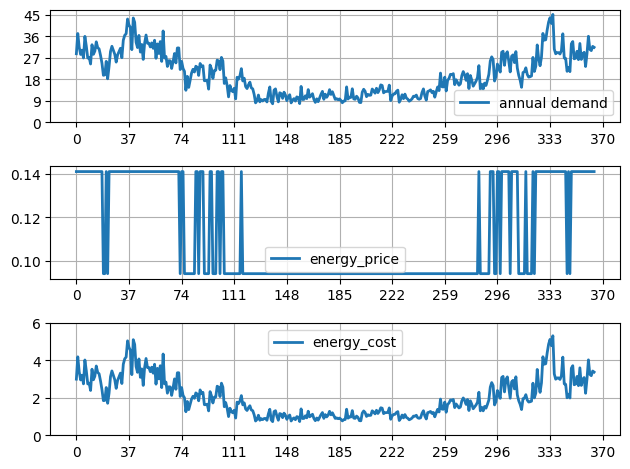

In [77]:
#  energy relation
fig, (ax1, ax2, ax3) = plt.subplots(3, 1)

ax1.plot(annual_daily_energy_demand, linewidth = 2, label = 'annual demand')
ax1.legend()
ax1.grid()
ax1.set_xticks(np.arange(0, 400, 37))
ax1.set_yticks(np.arange(0, max(annual_daily_energy_demand),  int(max(annual_daily_energy_demand)/5 )) )


ax2.plot(energy_price, linewidth = 2, label = 'energy_price')
ax2.legend()
ax2.grid()
ax2.set_xticks(np.arange(0, 400, 37))


ax3.plot(energy_cost, linewidth = 2, label = 'energy_cost')
ax3.legend()
ax3.grid()
ax3.set_xticks(np.arange(0, 400, 37))
ax3.set_yticks(np.arange(0, 8, 2))
plt.tight_layout() 
fig.savefig('../results/energy_pricing.png',dpi = 200)